🤖 ENTRAÎNEMENT DU MODÈLE DE LOCALISATION

📂 Chargement du dataset unifié...
✅ 6895 mesures chargées
📍 Salles: ['couloirB(2e)', 'couloirB', 'PALIER1ER', 'PALIER2E', 'S101A', 'S101B', 'S102A', 'S102B', 'S103B', 'S104', 'S202A', 'S202B', 'S203A', 'S203B', 'S204A', 'S204B']
📡 BSSID uniques: 6

🔧 Préparation des features...
✅ 6 BSSID utilisés comme features

🔄 Transformation en matrice de features...
✅ Matrice créée: 968 échantillons, 6 features

📊 Distribution des classes:
Room
S104            97
S101A           86
couloirB(2e)    85
PALIER1ER       76
S103B           73
PALIER2E        69
S203A           64
S203B           58
S202B           57
S204A           54
S204B           52
S101B           50
S202A           50
S102B           35
couloirB        32
S102A           30
Name: count, dtype: int64

💾 Encodeur sauvegardé: label_encoder.pkl

✂️  Split des données...
✅ Train: 726 échantillons
✅ Test: 242 échantillons

🎯 Entraînement du Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    0.8s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s



✅ Entraînement terminé !

📊 Évaluation du modèle...


[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.



🎯 Accuracy:
   Train: 96.42%
   Test: 73.14%


[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    0.9s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    0.9s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 200 out of 200 | 


🔄 Cross-validation (5-fold):
   Moyenne: 71.90% (±2.13%)

📋 Rapport de classification:
              precision    recall  f1-score   support

   PALIER1ER      0.682     0.789     0.732        19
    PALIER2E      0.692     0.529     0.600        17
       S101A      0.889     0.762     0.821        21
       S101B      0.769     0.769     0.769        13
       S102A      0.889     1.000     0.941         8
       S102B      0.889     0.889     0.889         9
       S103B      0.609     0.778     0.683        18
        S104      0.828     1.000     0.906        24
       S202A      0.692     0.750     0.720        12
       S202B      0.818     0.643     0.720        14
       S203A      0.625     0.625     0.625        16
       S203B      0.786     0.733     0.759        15
       S204A      0.412     0.500     0.452        14
       S204B      0.750     0.462     0.571        13
    couloirB      0.714     0.625     0.667         8
couloirB(2e)      0.800     0.762     0.780    

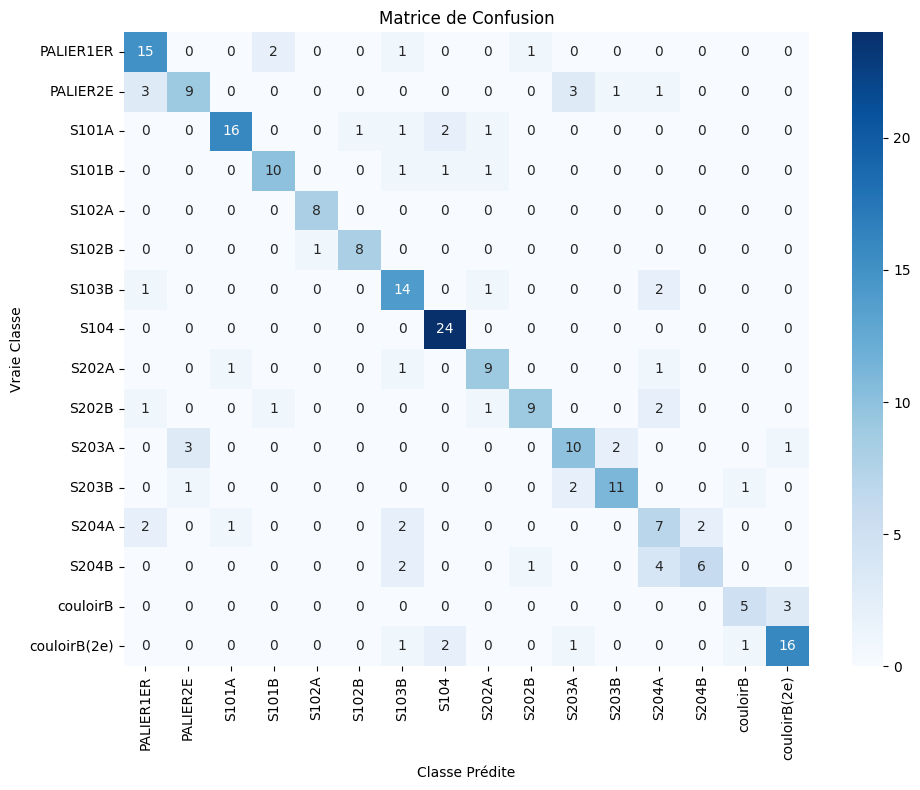


📡 Top 10 BSSID les plus discriminants:
            BSSID  Importance
ac:2a:a1:7e:df:65    0.250821
ac:2a:a1:7e:df:6a    0.195697
ac:2a:a1:7e:df:68    0.175422
ac:2a:a1:7e:df:67    0.152519
ac:2a:a1:7e:df:62    0.121550
ac:2a:a1:7e:df:61    0.103992

💾 Sauvegarde du modèle...
✅ Modèle sauvegardé: room_classifier.pkl
✅ Métadonnées: model_metadata.json

✅ Entraînement terminé avec succès !


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import json

# ============================================================
# CONFIGURATION
# ============================================================

CLEANED_DATA_DIR = Path("data/cleaned")
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

print("🤖 ENTRAÎNEMENT DU MODÈLE DE LOCALISATION")
print("=" * 60)

# ============================================================
# 1. CHARGEMENT DES DONNÉES
# ============================================================

print("\n📂 Chargement du dataset unifié...")

unified_file = CLEANED_DATA_DIR / "dataset_unified.csv"

if not unified_file.exists():
    print(f"❌ Fichier {unified_file} introuvable")
    print("Exécutez d'abord le notebook 1_data_cleaning.ipynb")
else:
    df = pd.read_csv(unified_file)
    print(f"✅ {len(df)} mesures chargées")
    print(f"📍 Salles: {df['Room'].unique().tolist()}")
    print(f"📡 BSSID uniques: {df['BSSID'].nunique()}")

# ============================================================
# 2. PRÉPARATION DES FEATURES
# ============================================================

print("\n🔧 Préparation des features...")

# Charger les BSSID communs depuis le rapport
with open(CLEANED_DATA_DIR / "cleaning_report.json", 'r') as f:
    report = json.load(f)
    common_bssids = report['common_bssids']

print(f"✅ {len(common_bssids)} BSSID utilisés comme features")

# Créer une matrice : chaque ligne = 1 mesure temporelle, colonnes = RSSI par BSSID
# Stratégie : regrouper par (Room, Time) et créer un vecteur de features

print("\n🔄 Transformation en matrice de features...")

# Grouper par timestamp (même moment = même observation)
df['Time'] = pd.to_datetime(df['Time'])

# Créer un identifiant unique par session de mesure
df = df.sort_values(['Room', 'Time'])

# Pivoter : une ligne par timestamp, une colonne par BSSID
df_pivot = df.pivot_table(
    index=['Room', 'Time'],
    columns='BSSID',
    values='RSSI(dBm)',
    aggfunc='mean'  # Si plusieurs mesures au même instant
).reset_index()

# Remplir les RSSI manquants par -100 (signal très faible = absent)
df_pivot = df_pivot.fillna(-100)

print(f"✅ Matrice créée: {df_pivot.shape[0]} échantillons, {df_pivot.shape[1]-2} features")

# Séparer X (features) et y (labels)
X = df_pivot.drop(columns=['Room', 'Time'])
y = df_pivot['Room']

print(f"\n📊 Distribution des classes:")
print(y.value_counts())

# ============================================================
# 3. ENCODAGE DES LABELS
# ============================================================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Sauvegarder l'encodeur
encoder_file = MODEL_DIR / "label_encoder.pkl"
joblib.dump(label_encoder, encoder_file)
print(f"\n💾 Encodeur sauvegardé: {encoder_file.name}")

# ============================================================
# 4. SPLIT TRAIN/TEST
# ============================================================

print("\n✂️  Split des données...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.25, 
    random_state=42,
    stratify=y_encoded
)

print(f"✅ Train: {len(X_train)} échantillons")
print(f"✅ Test: {len(X_test)} échantillons")

# ============================================================
# 5. ENTRAÎNEMENT DU MODÈLE
# ============================================================

print("\n🎯 Entraînement du Random Forest...")

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

model.fit(X_train, y_train)

print("\n✅ Entraînement terminé !")

# ============================================================
# 6. ÉVALUATION
# ============================================================

print("\n📊 Évaluation du modèle...")

# Score sur train et test
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f"\n🎯 Accuracy:")
print(f"   Train: {train_score:.2%}")
print(f"   Test: {test_score:.2%}")

# Cross-validation
cv_scores = cross_val_score(model, X_train, y_train, cv=5)
print(f"\n🔄 Cross-validation (5-fold):")
print(f"   Moyenne: {cv_scores.mean():.2%} (±{cv_scores.std():.2%})")

# Prédictions
y_pred = model.predict(X_test)

# Rapport de classification
print("\n📋 Rapport de classification:")
print(classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_,
    digits=3
))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title('Matrice de Confusion')
plt.ylabel('Vraie Classe')
plt.xlabel('Classe Prédite')
plt.tight_layout()
plt.savefig(MODEL_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

# Importance des features (BSSID)
feature_importance = pd.DataFrame({
    'BSSID': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📡 Top 10 BSSID les plus discriminants:")
print(feature_importance.head(10).to_string(index=False))

# ============================================================
# 7. SAUVEGARDE DU MODÈLE
# ============================================================

print("\n💾 Sauvegarde du modèle...")

model_file = MODEL_DIR / "room_classifier.pkl"
joblib.dump(model, model_file)

# Sauvegarder les métadonnées
metadata = {
    'feature_names': X.columns.tolist(),
    'class_names': label_encoder.classes_.tolist(),
    'train_score': float(train_score),
    'test_score': float(test_score),
    'cv_score_mean': float(cv_scores.mean()),
    'cv_score_std': float(cv_scores.std()),
    'n_samples_train': len(X_train),
    'n_samples_test': len(X_test),
    'n_features': X.shape[1]
}

metadata_file = MODEL_DIR / "model_metadata.json"
with open(metadata_file, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✅ Modèle sauvegardé: {model_file.name}")
print(f"✅ Métadonnées: {metadata_file.name}")

print("\n✅ Entraînement terminé avec succès !")
